In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
# Import provided data from multi-sheet xlsx files
folderpath = (
    Path("..")
    / "data"
    / "The Water Sector Meets Mathematics_ V-KEMS Virtual Study Group-20260323T171309Z-3-001"
    / "Challenge 1"
)
filepath = folderpath / "VKEMS challenge 1 data.xlsx"
with open(filepath, "r") as file:
    df = pd.read_excel(filepath, sheet_name=None)

# Show imported Excel sheet names
for key in df.keys():
    df[key] = df[key].set_index(df[key].columns[0])
print(df.keys())

dict_keys(['Zones', 'ESW', 'NW'])


In [12]:
weather_path = Path(".") / "weekly_weather_data"
for zone in df["Zones"].index:
    file = weather_path / f"weather_data_weekly_{zone}.csv"
    df_tmp = pd.read_csv(file).set_index("date")

df_tmp.head()

,temperature_2m_min,temperature_2m_mean,temperature_2m_max,soil_temperature_100_to_255cm_min,soil_temperature_100_to_255cm_mean,soil_temperature_100_to_255cm_max,soil_moisture_100_to_255cm_min,soil_moisture_100_to_255cm_mean,soil_moisture_100_to_255cm_max,precipitation_min,precipitation_mean,precipitation_max
date,,,,,,,,,,,,
2001-12-30 00:00:00+00:00,-3.582,1.307881,7.718,7.818,8.118893,8.418,0.371,0.371512,0.372,0.0,0.042857,0.6
2002-01-06 00:00:00+00:00,-7.432,-0.945988,5.018,7.118,7.457285,7.818,0.372,0.372827,0.373,0.0,0.005357,0.4
2002-01-13 00:00:00+00:00,-1.332,3.652524,9.418,6.418,6.747166,7.068,0.373,0.373976,0.374,0.0,0.015476,0.6
2002-01-20 00:00:00+00:00,1.368,5.790321,9.868,6.118,6.256095,6.418,0.374,0.374321,0.375,0.0,0.061905,1.4
2002-01-27 00:00:00+00:00,-3.182,6.205798,11.518,5.968,6.034964,6.118,0.375,0.375000,0.375,0.0,0.109524,1.7


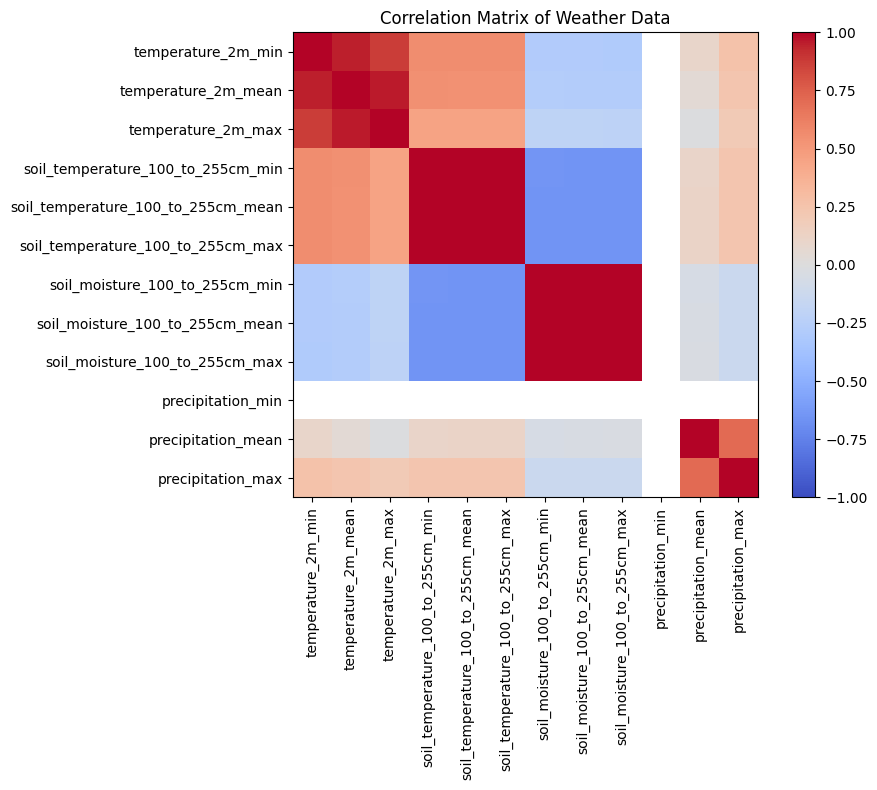

In [20]:
# Plot correlation matrix between each column of df_tmp
corr = df_tmp.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix of Weather Data")
plt.tight_layout()
plt.show()